# 📘 Tutorial Prático: Sua Primeira Rede Neural Convolucional (CNN)

**Objetivo:** Criar a rede convolução mais básica de todas capaz de ler números escritos à mão (Dataset MNIST).

Neste notebook, vamos focar em entender **o que** cada parte do código faz, de forma didática.

## 1. Importando as Ferramentas
Vamos usar o **TensorFlow/Keras** para criar a rede neural e o **Matplotlib** para desenhar os gráficos e imagens.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, datasets


tf.random.set_seed(1895) # Ano de fundação do CRF

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


## 2. Carregando e Preparando os Dados (ETL)
O dataset **MNIST** é famoso. Ele já vem dividido em:
* **Treino (x_train, y_train):** 60.000 imagens para a IA estudar.
* **Teste (x_test, y_test):** 10.000 imagens para aplicarmos uma "prova" nela depois.

**Importante:** Redes neurais gostam de números pequenos (entre 0 e 1). Por isso, dividimos os valores dos pixels (que vão de 0 a 255) por 255.0.

In [19]:
# Carregando os dados
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Normalização (0-255 -> 0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print('Formato do conjunto de treino:', x_train.shape)
print('Formato do conjunto de teste:', x_test.shape)


Formato do conjunto de treino: (60000, 28, 28, 1)
Formato do conjunto de teste: (10000, 28, 28, 1)


## 3. Visualizando o Dataset
Antes de treinar, vamos ver como essas imagens se parecem.

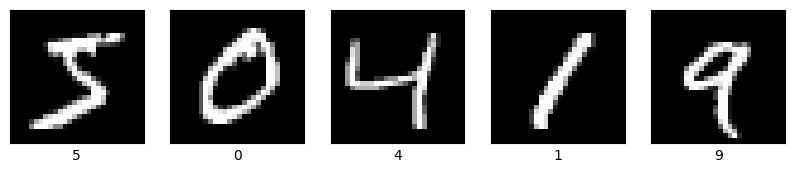

In [20]:
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.xlabel(y_train[i])
plt.show()

## 4. Construindo a Rede Neural (Arquitetura)
Vamos usar o modelo `Sequential` (uma camada após a outra).

1.  **Conv2D:** Passa filtros na imagem para achar bordas e curvas.
2.  **MaxPooling2D:** Reduz a imagem, mantendo apenas o que importa (resume a informação).
3.  **Flatten:** Transforma a matriz quadrada em uma linha reta (vetor).
4.  **Dense (Softmax):** A última camada tem 10 neurônios (um para cada dígito 0-9) e nos dá a probabilidade.

In [21]:
# Construindo a arquitetura
model = models.Sequential(name='cnn_mnist')

## Extração de features
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

## Extração de features
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Rede Neural Densa
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))

# Output
model.add(layers.Dense(10, activation='softmax'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

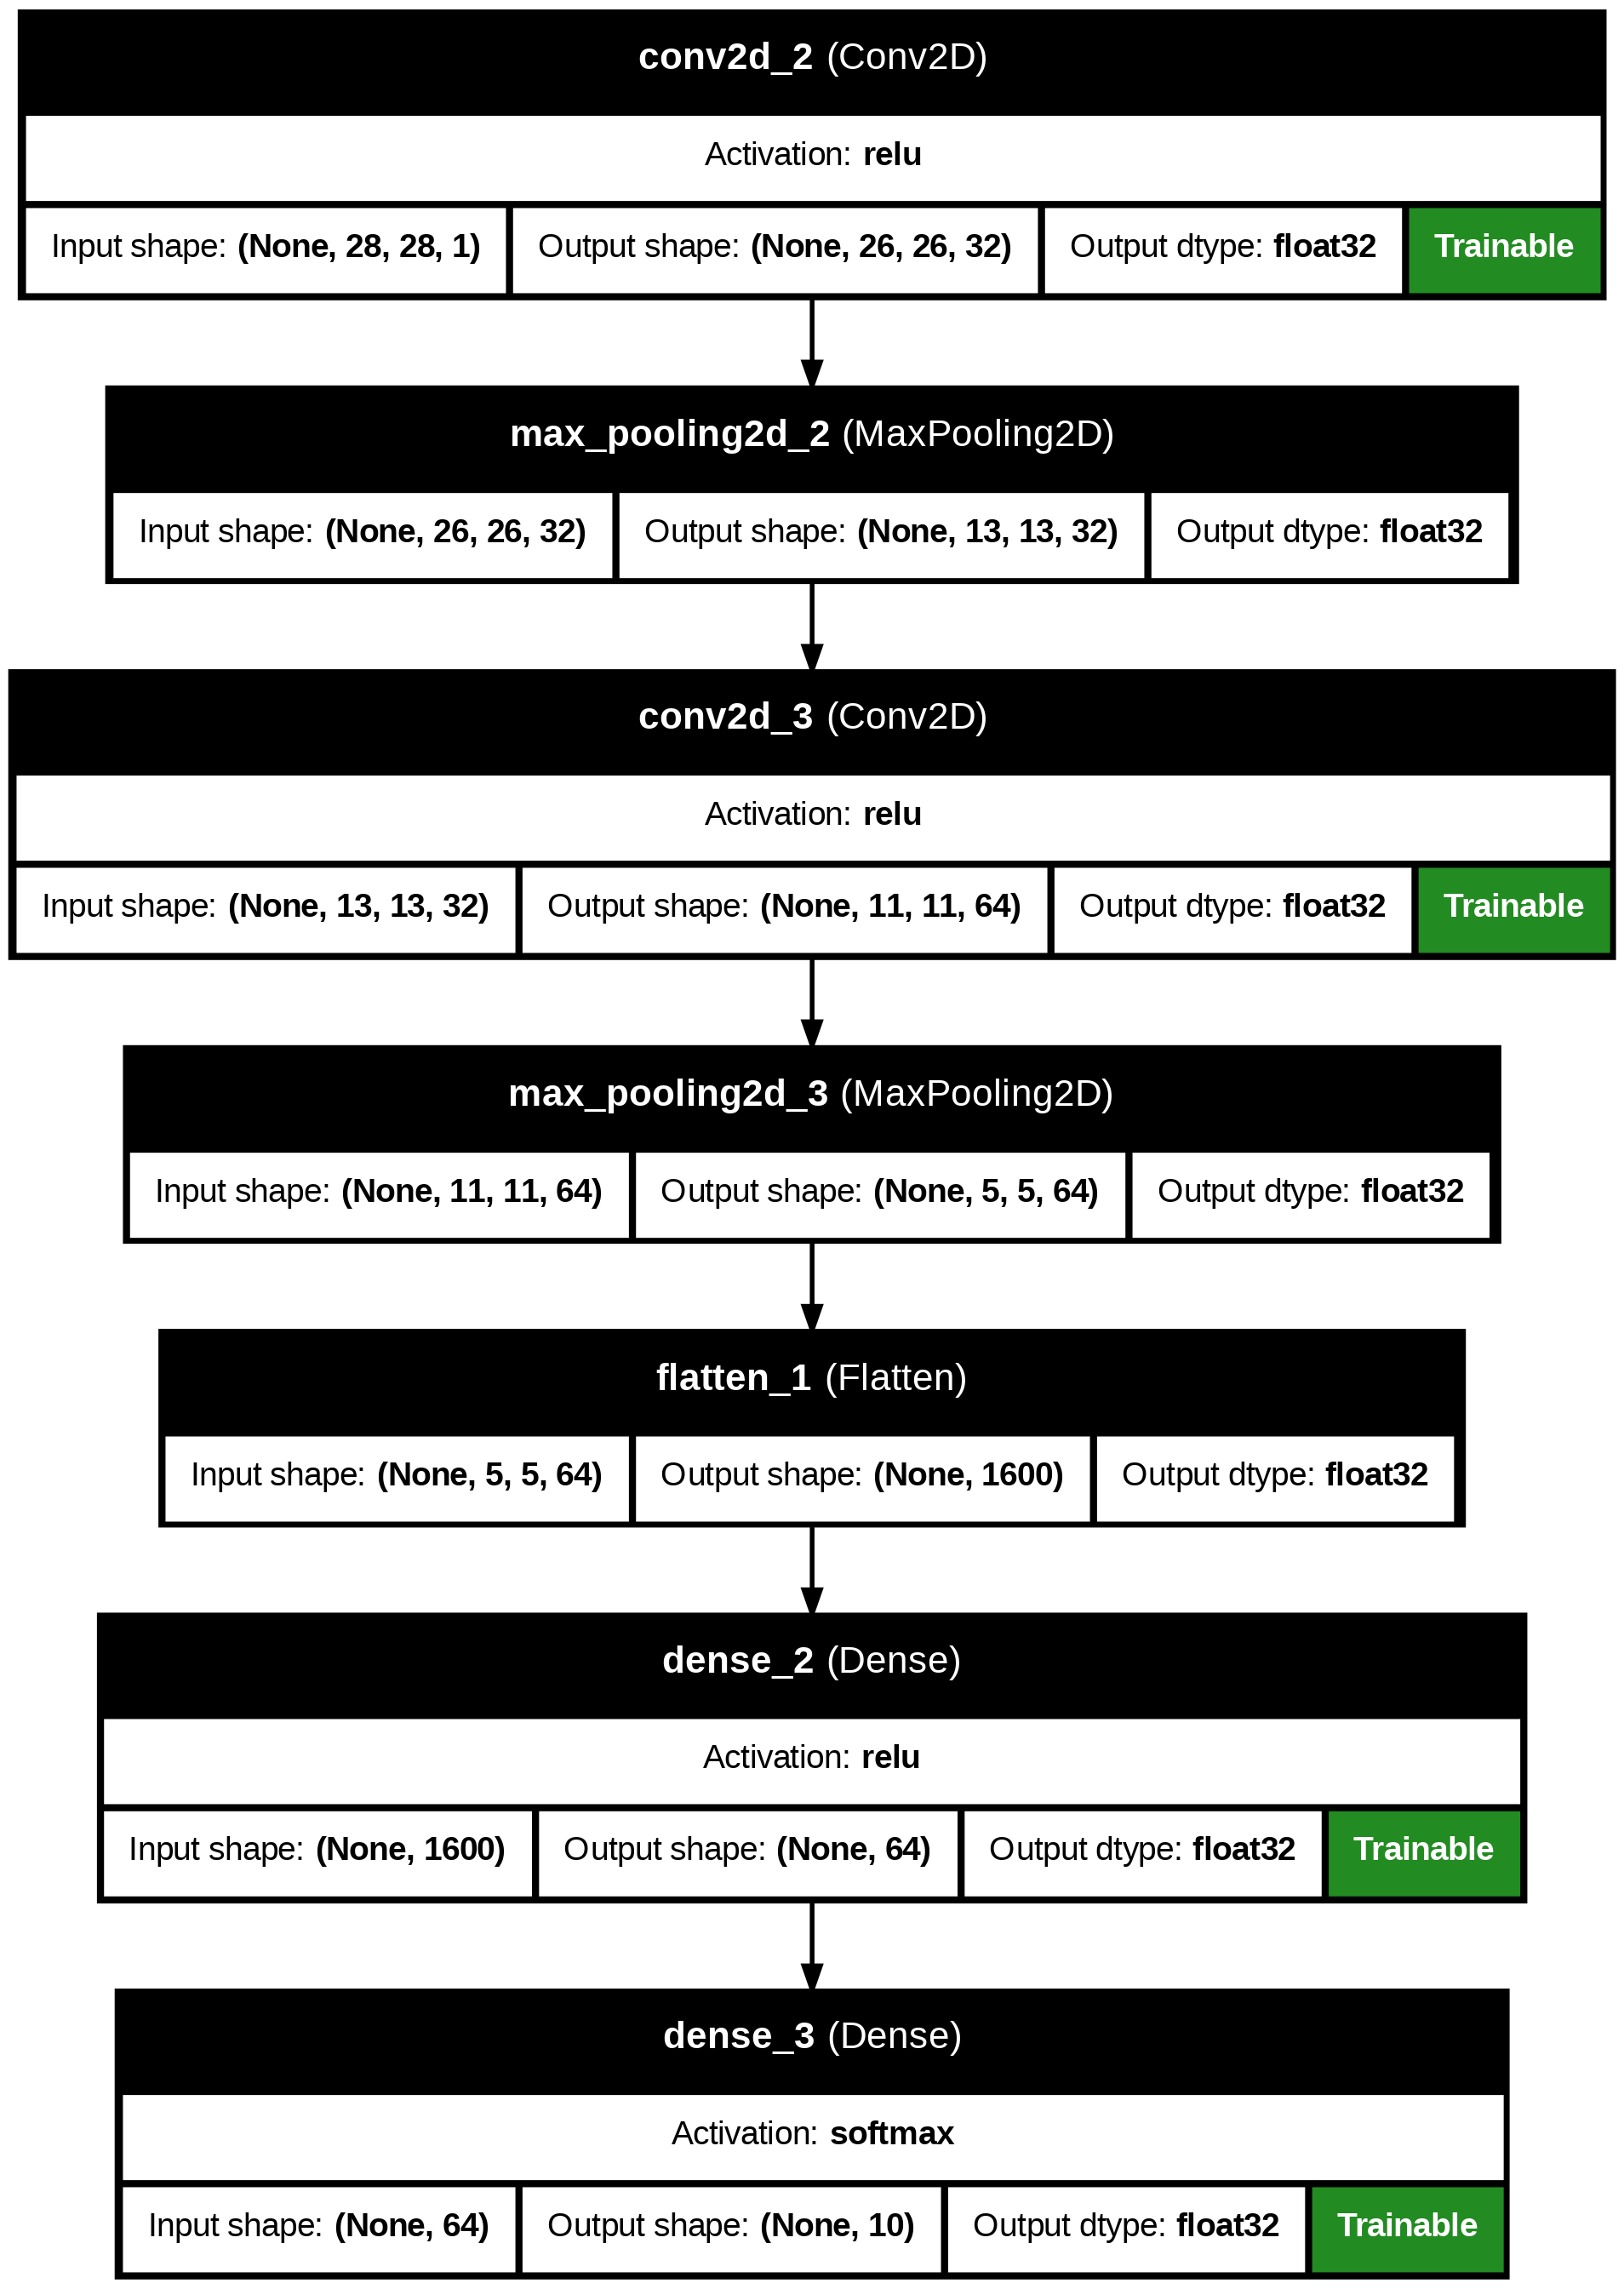

In [23]:
tf.keras.utils.plot_model(
    model,
    to_file='model.png',
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=True,
    dpi=200,
    show_layer_activations=True,
    show_trainable=True
)


## 5. Treinamento
Agora vamos ensinar a rede.
* **Epochs (Épocas):** Quantas vezes a rede vai ver o dataset completo (vamos usar 5).
* **Loss (Perda):** Usamos `sparse_categorical_crossentropy` porque nossos rótulos são números inteiros (ex: 5, 0, 1).

In [9]:
# Compilando e treinando a rede
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=2
)


Epoch 1/5
469/469 - 42s - 89ms/step - accuracy: 0.9303 - loss: 0.2341 - val_accuracy: 0.9769 - val_loss: 0.0739
Epoch 2/5
469/469 - 40s - 85ms/step - accuracy: 0.9808 - loss: 0.0636 - val_accuracy: 0.9855 - val_loss: 0.0438
Epoch 3/5
469/469 - 39s - 83ms/step - accuracy: 0.9861 - loss: 0.0457 - val_accuracy: 0.9872 - val_loss: 0.0368
Epoch 4/5
469/469 - 39s - 84ms/step - accuracy: 0.9890 - loss: 0.0359 - val_accuracy: 0.9872 - val_loss: 0.0365
Epoch 5/5
469/469 - 39s - 83ms/step - accuracy: 0.9908 - loss: 0.0290 - val_accuracy: 0.9861 - val_loss: 0.0414


## 6. Avaliação dos Resultados
Vamos ver um gráfico da evolução da acurácia (precisão) e fazer um teste final.

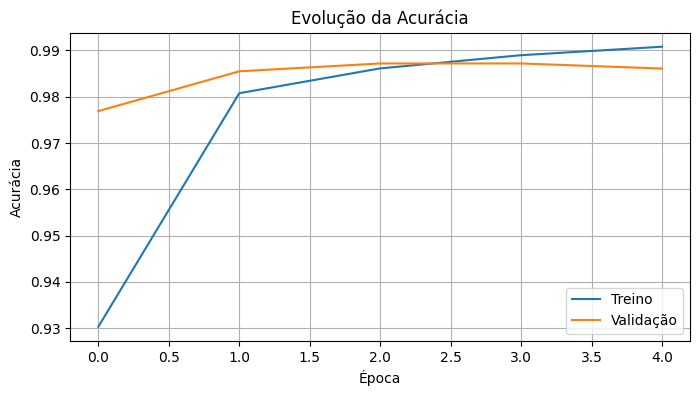

Acurácia no conjunto de teste: 0.9861
Loss no conjunto de teste: 0.0414


In [12]:
# Plota o gráfico de acurácia
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia')
plt.legend()
plt.grid(True)
plt.show()

# Avaliação numérica final
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Acurácia no conjunto de teste: {test_acc:.4f}')
print(f'Loss no conjunto de teste: {test_loss:.4f}')


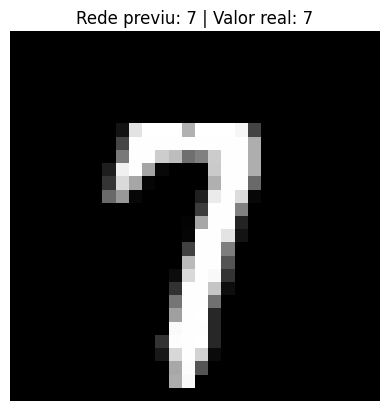

In [15]:
# Exemplo de previsão
idx = np.random.randint(0, len(x_test))
sample = x_test[idx:idx+1]
prediction = np.argmax(model.predict(sample, verbose=0))
plt.imshow(sample.reshape(28, 28), cmap='gray')
plt.title(f'Rede previu: {prediction} | Valor real: {y_test[idx]}')
plt.axis('off')
plt.show()